<a href="https://colab.research.google.com/github/snehasri2600/Testing-Only/blob/main/FSHRI_Final_Dataset_Prep_and_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Data Cleaning and Preparation

In [1]:
# Install dependencies and import libraries
!pip install geopandas -q

import geopandas as gpd
import pandas as pd

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Import dataset from data.cityofnewyork.us and convert to geodataframe
from shapely.geometry import shape
fvi_original = pd.read_json('https://data.cityofnewyork.us/resource/mrjc-v9pm.json?$limit=99999999999')
fvi_original['the_geom'] = fvi_original['the_geom'].apply(shape)
fvi_gdf = gpd.GeoDataFrame(fvi_original, geometry='the_geom')

In [4]:
# Import remaining datasets from Google Drive
income_file         = "/content/drive/MyDrive/ColabNotebooks/PIT_Presentation/Tract_2.csv"              # ACS median income CSV
neighborhood_file   = "/content/drive/MyDrive/ColabNotebooks/PIT_Presentation/2020_Census_Tracts_20260318.zip"           # tract-to-neighborhood shapefile

In [5]:
# Read in the datasets
income_gdf = gpd.read_file(income_file)
neighborhoods_gdf = gpd.read_file(neighborhood_file)

In [6]:
# Display datasets for exploration
display(fvi_gdf.head())
display(income_gdf.head())
display(neighborhoods_gdf.head())

,the_geom,geoid,fshri,ss_80s,ss_cur,ss_50s,tid_80s,tid_20s,tid_50s
0,"MULTIPOLYGON (((-73.90183 40.81915, -73.90167 ...",36005008500,5.0,NaN,NaN,NaN,NaN,NaN,NaN
1,"MULTIPOLYGON (((-73.84472 40.68071, -73.84307 ...",36081008600,5.0,NaN,NaN,NaN,NaN,NaN,NaN
2,"MULTIPOLYGON (((-73.95776 40.60099, -73.95683 ...",36047058000,5.0,2.0,NaN,NaN,NaN,NaN,NaN
3,"MULTIPOLYGON (((-73.9623 40.62996, -73.96137 4...",36047053200,5.0,NaN,NaN,NaN,NaN,NaN,NaN
4,"MULTIPOLYGON (((-73.93859 40.76682, -73.93618 ...",36081004500,5.0,5.0,2.0,5.0,NaN,NaN,NaN


,Object ID,Geographic Identifier - FIPS Code,Tract Name,Area of Land (Square Meters),Area of Water (Square Meters),State Name,County Name,Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range),Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range) - Margin of Error,"Median Household Income in past 12 months, Householder under 25 years",...,Total Households,Total Households - Margin of Error,Households with any self-employment income in past 12 months,Households with any self-employment income in past 12 months - Margin of Error,Households with no self-employment income in past 12 months,Households with no self-employment income in past 12 months - Margin of Error,Percent of households with any self-employment income,Percent of households with any self-employment income - Margin of Error,Shape Area,Shape Length
0,1,12009062115,Census Tract 621.15,9044814,0,Florida,Brevard County,71268,25187,,...,815,218,180,186,635,139,22.1,22.0442154031738,11731331.1464844,13977.6534429529
1,2,12009062301,Census Tract 623.01,2682013,14427,Florida,Brevard County,41125,11466,,...,1341,266,72,64,1269,259,5.4,4.65220877431107,3495468.79101563,8558.00189353554
2,3,12009062302,Census Tract 623.02,2831784,0,Florida,Brevard County,35480,8242,,...,1563,354,62,49,1501,356,4,3.00350718758752,3672045.16210938,8991.1986135111
3,4,12009062401,Census Tract 624.01,6137867,332858,Florida,Brevard County,52057,4179,,...,922,186,99,91,823,165,10.7,9.62921310374469,8391051.68945313,13863.2473317914
4,5,12009062402,Census Tract 624.02,5882534,2843,Florida,Brevard County,34810,12318,67634,...,2385,369,217,154,2168,416,9.1,6.30170886439203,7629695.20703125,12996.4643068565


,ctlabel,borocode,boroname,ct2020,boroct2020,cdeligibil,ntaname,nta2020,cdta2020,cdtaname,geoid,shape_leng,shape_area,geometry
0,1,1,Manhattan,000100,1000100,I,The Battery-Governors Island-Ellis Island-Libe...,MN0191,MN01,MN01 Financial District-Tribeca (CD 1 Equivalent),36061000100,10833.043929,1.843005e+06,"MULTIPOLYGON (((-74.04388 40.69019, -74.04351 ..."
1,22.01,1,Manhattan,002201,1002201,E,Lower East Side,MN0302,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),36061002201,5779.062607,1.740174e+06,"POLYGON ((-73.97875 40.71993, -73.97879 40.719..."
2,26.02,1,Manhattan,002602,1002602,E,East Village,MN0303,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),36061002602,4491.203220,1.114857e+06,"POLYGON ((-73.97559 40.72428, -73.97593 40.723..."
3,28,1,Manhattan,002800,1002800,E,East Village,MN0303,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),36061002800,5627.555089,1.973679e+06,"POLYGON ((-73.9733 40.72743, -73.9738 40.72675..."
4,34,1,Manhattan,003400,1003400,I,East Village,MN0303,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),36061003400,5503.307044,1.718452e+06,"POLYGON ((-73.97803 40.72943, -73.97806 40.729..."


In [7]:
# Print income columns to find the location-identifying column (some version of geoid)
print(income_gdf.columns.tolist)

<bound method IndexOpsMixin.tolist of Index(['Object ID', 'Geographic Identifier - FIPS Code', 'Tract Name',
       'Area of Land (Square Meters)', 'Area of Water (Square Meters)',
       'State Name', 'County Name',
       'Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range)',
       'Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range) - Margin of Error',
       'Median Household Income in past 12 months, Householder under 25 years',
       'Median Household Income in past 12 months, Householder under 25 years - Margin of Error',
       'Median Household Income in past 12 months, Householder 25 to 44 years',
       'Median Household Income in past 12 months, Householder 25 to 44 years - Margin of Error',
       'Median Household Income in past 12 months, Householder 45 to 64 years',
       'Median Household Income in past 12 months, Householder 45 to 64 years - Margin of Error',
       'Med

In [8]:
# Rename the income GEOID column to match the others
income_gdf = income_gdf.rename(columns={"Geographic Identifier - FIPS Code": "geoid"})

# Ensure all three are strings, zero-padded to 11 digits
fvi_gdf["geoid"] = fvi_gdf["geoid"].astype(str).str.zfill(11)
income_gdf["geoid"] = income_gdf["geoid"].astype(str).str.zfill(11)
neighborhoods_gdf["geoid"] = neighborhoods_gdf["geoid"].astype(str).str.zfill(11)

# Merge the three datasets into one
merged = fvi_gdf.merge(income_gdf, on="geoid", how="left")
merged = merged.merge(neighborhoods_gdf, on="geoid", how="left")

print(merged.shape)
print(merged.isnull().sum())

(2209, 64)
the_geom         0
geoid            0
fshri            2
ss_80s        1597
ss_cur        1848
              ... 
cdta2020         0
cdtaname         0
shape_leng       0
shape_area       0
geometry         0
Length: 64, dtype: int64


In [9]:
# Locate the counties relevant to this analysis (the five boroughs of NYC) and filter the dataset accordingly

#Locating the counties
desired_counties = [
    'Bronx County', #Bronx
    'Kings County', # Brooklyn
    'Richmond County', # Staten Island
    'New York County', # Manhattan
    'Queens County' # Queens
]

# Filtering the merged DataFrame
merged_filtered = merged[merged['County Name'].isin(desired_counties)]

print(f"Shape of filtered DataFrame: {merged_filtered.shape}")
print(merged_filtered['County Name'].value_counts())

Shape of filtered DataFrame: (2209, 64)
County Name
Kings County       774
Queens County      678
Bronx County       340
New York County    300
Richmond County    117
Name: count, dtype: int64


In [10]:
#View filtered dataframe
display(merged_filtered)

,the_geom,geoid,fshri,ss_80s,ss_cur,ss_50s,tid_80s,tid_20s,tid_50s,Object ID,...,ct2020,boroct2020,cdeligibil,ntaname,nta2020,cdta2020,cdtaname,shape_leng,shape_area,geometry
0,"MULTIPOLYGON (((-73.90183 40.81915, -73.90167 ...",36005008500,5.0,NaN,NaN,NaN,NaN,NaN,NaN,67464,...,008500,2008500,E,Longwood,BX0202,BX02,BX02 Longwood-Hunts Point (CD 2 Approximation),6463.499306,1.966132e+06,"POLYGON ((-73.89704 40.8168, -73.89621 40.8163..."
1,"MULTIPOLYGON (((-73.84472 40.68071, -73.84307 ...",36081008600,5.0,NaN,NaN,NaN,NaN,NaN,NaN,69631,...,008600,4008600,I,Ozone Park,QN1002,QN10,QN10 South Ozone Park-Howard Beach (CD 10 Appr...,8145.399567,3.562476e+06,"POLYGON ((-73.83952 40.67996, -73.83794 40.676..."
2,"MULTIPOLYGON (((-73.95776 40.60099, -73.95683 ...",36047058000,5.0,2.0,NaN,NaN,NaN,NaN,NaN,68577,...,058000,3058000,E,Madison,BK1502,BK15,BK15 Sheepshead Bay-Gravesend (East) (CD 15 Ap...,5340.456417,1.707766e+06,"POLYGON ((-73.95315 40.59703, -73.95411 40.596..."
3,"MULTIPOLYGON (((-73.9623 40.62996, -73.96137 4...",36047053200,5.0,NaN,NaN,NaN,NaN,NaN,NaN,68533,...,053200,3053200,E,Midwood,BK1403,BK14,BK14 Flatbush-Midwood (CD 14 Approximation),6887.340443,1.876179e+06,"POLYGON ((-73.95899 40.62789, -73.95854 40.625..."
4,"MULTIPOLYGON (((-73.93859 40.76682, -73.93618 ...",36081004500,5.0,5.0,2.0,5.0,NaN,NaN,NaN,69605,...,004500,4004500,I,Queensbridge-Ravenswood-Dutch Kills,QN0105,QN01,QN01 Astoria-Queensbridge (CD 1 Equivalent),7941.412066,2.375492e+06,"POLYGON ((-73.93494 40.76701, -73.93363 40.766..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2204,"MULTIPOLYGON (((-73.98639 40.74592, -73.98595 ...",36061007400,1.0,NaN,NaN,NaN,NaN,NaN,NaN,69208,...,007400,1007400,I,Midtown South-Flatiron-Union Square,MN0501,MN05,MN05 Midtown-Flatiron-Union Square (CD 5 Appro...,5726.157650,1.879420e+06,"POLYGON ((-73.98085 40.74775, -73.98134 40.747..."
2205,"MULTIPOLYGON (((-74.02064 40.73039, -74.02006 ...",36061006900,1.0,3.0,2.0,3.0,NaN,NaN,NaN,69202,...,006900,1006900,I,West Village,MN0203,MN02,MN02 Greenwich Village-SoHo (CD 2 Equivalent),7531.257104,2.362610e+06,"POLYGON ((-74.00662 40.73167, -74.00674 40.730..."
2206,"MULTIPOLYGON (((-73.96439 40.80734, -73.96417 ...",36061020300,1.0,NaN,NaN,NaN,NaN,NaN,NaN,69364,...,020300,1020300,I,Morningside Heights,MN0901,MN09,MN09 Morningside Heights-Hamilton Heights (CD ...,6065.202681,1.916857e+06,"POLYGON ((-73.95827 40.81063, -73.95872 40.810..."
2207,"MULTIPOLYGON (((-73.90307 40.80988, -73.89917 ...",36005009302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67471,...,009302,2009302,I,Hunts Point,BX0201,BX02,BX02 Longwood-Hunts Point (CD 2 Approximation),32163.459912,1.908350e+07,"POLYGON ((-73.88201 40.81083, -73.88182 40.810..."


In [11]:
# View complete list of columns to check which ones are relevant to this study
print(merged_filtered.columns.tolist)

<bound method IndexOpsMixin.tolist of Index(['the_geom', 'geoid', 'fshri', 'ss_80s', 'ss_cur', 'ss_50s', 'tid_80s',
       'tid_20s', 'tid_50s', 'Object ID', 'Tract Name',
       'Area of Land (Square Meters)', 'Area of Water (Square Meters)',
       'State Name', 'County Name',
       'Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range)',
       'Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range) - Margin of Error',
       'Median Household Income in past 12 months, Householder under 25 years',
       'Median Household Income in past 12 months, Householder under 25 years - Margin of Error',
       'Median Household Income in past 12 months, Householder 25 to 44 years',
       'Median Household Income in past 12 months, Householder 25 to 44 years - Margin of Error',
       'Median Household Income in past 12 months, Householder 45 to 64 years',
       'Median Household Income in past 12 mon

In [12]:
# Filter the dataset to keep only those columns that are relevant
columns_to_keep = [
    'the_geom',
    'geoid',
    'fshri',
    'Tract Name',
    'State Name',
    'County Name',
    'Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range)',
    'boroname',
    'ntaname',
    'nta2020',
    'cdta2020',
    'cdtaname',
    'shape_leng',
    'shape_area',
    'geometry'
]

final_gdf = merged_filtered[columns_to_keep]

display(final_gdf.head())
print(f"Shape of final DataFrame: {final_gdf.shape}")

,the_geom,geoid,fshri,Tract Name,State Name,County Name,Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range),boroname,ntaname,nta2020,cdta2020,cdtaname,shape_leng,shape_area,geometry
0,"MULTIPOLYGON (((-73.90183 40.81915, -73.90167 ...",36005008500,5.0,Census Tract 85,New York,Bronx County,41535,Bronx,Longwood,BX0202,BX02,BX02 Longwood-Hunts Point (CD 2 Approximation),6463.499306,1.966132e+06,"POLYGON ((-73.89704 40.8168, -73.89621 40.8163..."
1,"MULTIPOLYGON (((-73.84472 40.68071, -73.84307 ...",36081008600,5.0,Census Tract 86,New York,Queens County,89667,Queens,Ozone Park,QN1002,QN10,QN10 South Ozone Park-Howard Beach (CD 10 Appr...,8145.399567,3.562476e+06,"POLYGON ((-73.83952 40.67996, -73.83794 40.676..."
2,"MULTIPOLYGON (((-73.95776 40.60099, -73.95683 ...",36047058000,5.0,Census Tract 580,New York,Kings County,38945,Brooklyn,Madison,BK1502,BK15,BK15 Sheepshead Bay-Gravesend (East) (CD 15 Ap...,5340.456417,1.707766e+06,"POLYGON ((-73.95315 40.59703, -73.95411 40.596..."
3,"MULTIPOLYGON (((-73.9623 40.62996, -73.96137 4...",36047053200,5.0,Census Tract 532,New York,Kings County,72500,Brooklyn,Midwood,BK1403,BK14,BK14 Flatbush-Midwood (CD 14 Approximation),6887.340443,1.876179e+06,"POLYGON ((-73.95899 40.62789, -73.95854 40.625..."
4,"MULTIPOLYGON (((-73.93859 40.76682, -73.93618 ...",36081004500,5.0,Census Tract 45,New York,Queens County,97462,Queens,Queensbridge-Ravenswood-Dutch Kills,QN0105,QN01,QN01 Astoria-Queensbridge (CD 1 Equivalent),7941.412066,2.375492e+06,"POLYGON ((-73.93494 40.76701, -73.93363 40.766..."


Shape of final DataFrame: (2209, 15)


In [13]:
# Check for null values
print(final_gdf.isnull().sum())

the_geom                                                                                               0
geoid                                                                                                  0
fshri                                                                                                  2
Tract Name                                                                                             0
State Name                                                                                             0
County Name                                                                                            0
Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range)    0
boroname                                                                                               0
ntaname                                                                                                0
nta2020                                                

In [14]:
# Confirm the final list of columns
print(final_gdf.columns.tolist)

<bound method IndexOpsMixin.tolist of Index(['the_geom', 'geoid', 'fshri', 'Tract Name', 'State Name', 'County Name',
       'Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range)',
       'boroname', 'ntaname', 'nta2020', 'cdta2020', 'cdtaname', 'shape_leng',
       'shape_area', 'geometry'],
      dtype='object')>


In [15]:
# Drop the redundant geometry column
final_gdf = final_gdf.drop(columns=['geometry'])
print(final_gdf.columns.tolist())

['the_geom', 'geoid', 'fshri', 'Tract Name', 'State Name', 'County Name', 'Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range)', 'boroname', 'ntaname', 'nta2020', 'cdta2020', 'cdtaname', 'shape_leng', 'shape_area']


In [16]:
# Rename columns to readable names and display the dataframe
final_gdf.rename(columns={'Median Household Income in past 12 months (inflation-adjusted dollars to last year of 5-year range)': 'Median Income', 'fshri': 'FSHRI', 'ntaname':'Neighborhood', 'boroname':'Borough'}, inplace=True)
display(final_gdf.head())

,the_geom,geoid,FSHRI,Tract Name,State Name,County Name,Median Income,Borough,Neighborhood,nta2020,cdta2020,cdtaname,shape_leng,shape_area
0,"MULTIPOLYGON (((-73.90183 40.81915, -73.90167 ...",36005008500,5.0,Census Tract 85,New York,Bronx County,41535,Bronx,Longwood,BX0202,BX02,BX02 Longwood-Hunts Point (CD 2 Approximation),6463.499306,1.966132e+06
1,"MULTIPOLYGON (((-73.84472 40.68071, -73.84307 ...",36081008600,5.0,Census Tract 86,New York,Queens County,89667,Queens,Ozone Park,QN1002,QN10,QN10 South Ozone Park-Howard Beach (CD 10 Appr...,8145.399567,3.562476e+06
2,"MULTIPOLYGON (((-73.95776 40.60099, -73.95683 ...",36047058000,5.0,Census Tract 580,New York,Kings County,38945,Brooklyn,Madison,BK1502,BK15,BK15 Sheepshead Bay-Gravesend (East) (CD 15 Ap...,5340.456417,1.707766e+06
3,"MULTIPOLYGON (((-73.9623 40.62996, -73.96137 4...",36047053200,5.0,Census Tract 532,New York,Kings County,72500,Brooklyn,Midwood,BK1403,BK14,BK14 Flatbush-Midwood (CD 14 Approximation),6887.340443,1.876179e+06
4,"MULTIPOLYGON (((-73.93859 40.76682, -73.93618 ...",36081004500,5.0,Census Tract 45,New York,Queens County,97462,Queens,Queensbridge-Ravenswood-Dutch Kills,QN0105,QN01,QN01 Astoria-Queensbridge (CD 1 Equivalent),7941.412066,2.375492e+06


In [17]:
# Convert the dataset to a GeoJSON for import into ArcGIS, if needed
final_gdf.to_file("merged_final_fshri.geojson", driver="GeoJSON")

/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [18]:
# Commented out code to download the dataset as a GeoJSON, can be run if desired
# from google.colab import files
# files.download('merged_final_fshri.geojson')

In [19]:
# Convert the dataset to a CSV for import into kepler.gl, if needed
final_gdf.to_csv("merged_final_fshri.csv", index=False)

In [20]:
# Commented out code to download the dataset as a CSV, can be run if desired
# from google.colab import files
# files.download('merged_final_fshri.csv')

## Data Visualization and Analysis

In [21]:
# Import libraries
import matplotlib.pyplot as plt
import seaborn as sns

The following visualization is designed to view the number of census tracts measured in each borough, and to compare the counts of FSHRI values in each of those tracts.

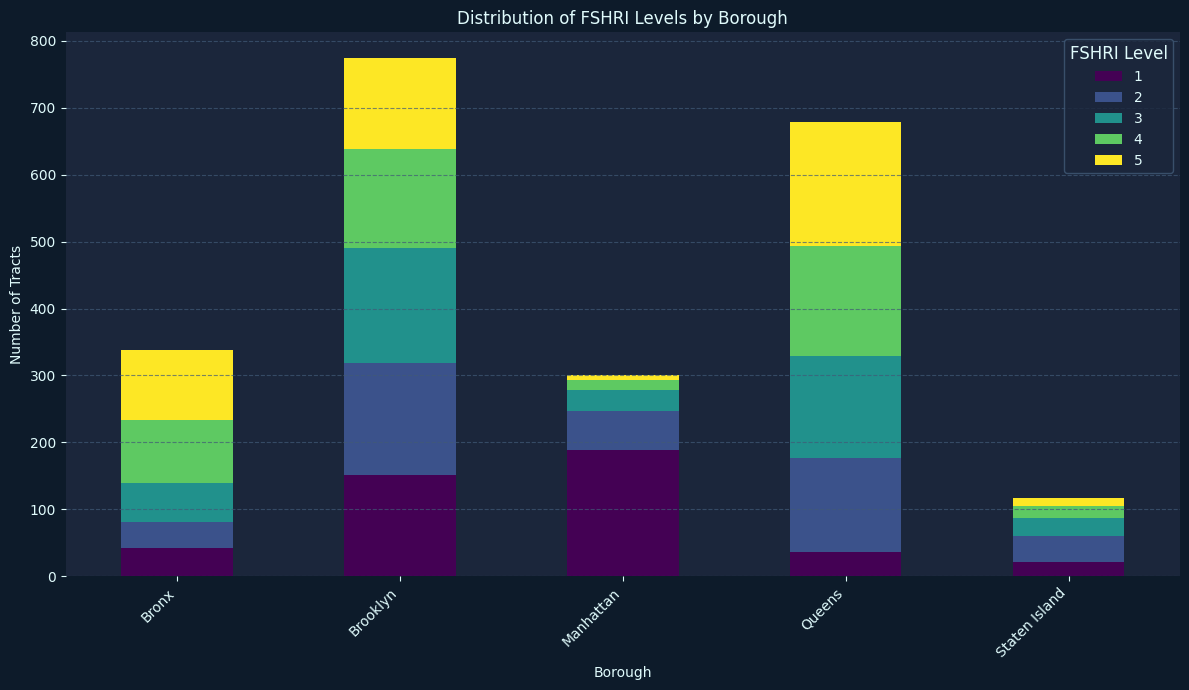

In [22]:
# Define the ocean-floor palette colors
fig_bg_color = '#0D1B2A'
ax_face_color = '#1B263B'
grid_color = '#415A77'
font_color = '#E0FBFC'

# Drop rows where FSHRI is NaN for this visualization
plot_df = final_gdf.dropna(subset=['FSHRI']).copy()

# Ensure FSHRI is an integer for categorical stacking, assuming it's a score from 1-5
plot_df['FSHRI_level'] = plot_df['FSHRI'].astype(int)

# Calculate counts of each FSHRI level per Borough
fshri_counts_by_borough = plot_df.groupby(['Borough', 'FSHRI_level']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 7), facecolor=fig_bg_color) # Set figure background to very dark blue
ax = fshri_counts_by_borough.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca()) # Use viridis for FSHRI levels

# Set the facecolor of the axes to a slightly lighter dark blue
ax.set_facecolor(ax_face_color)

plt.title('Distribution of FSHRI Levels by Borough', color=font_color)
plt.xlabel('Borough', color=font_color)
plt.ylabel('Number of Tracts', color=font_color)
plt.xticks(rotation=45, ha='right', color=font_color)
plt.yticks(color=font_color)

# Set tick label colors to a very light blue/cyan
ax.tick_params(axis='x', colors=font_color)
ax.tick_params(axis='y', colors=font_color)

# Adjust legend for dark background
legend = ax.legend(title='FSHRI Level', title_fontsize='12', fontsize='10',
                   facecolor=ax_face_color, edgecolor=grid_color, labelcolor=font_color)
plt.setp(legend.get_texts(), color=font_color) # Set text color for legend entries
plt.setp(legend.get_title(), color=font_color) # Set text color for legend title

# Set grid lines only for the y-axis
ax.grid(axis='y', linestyle='--', alpha=0.7, color=grid_color)
ax.grid(axis='x', visible=False) # Ensure x-axis grid is off

# Remove all borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

The following visualization takes the mean FSHRI score for each borough and plots it to compare values between the boroughs.

/tmp/ipykernel_11358/631184575.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


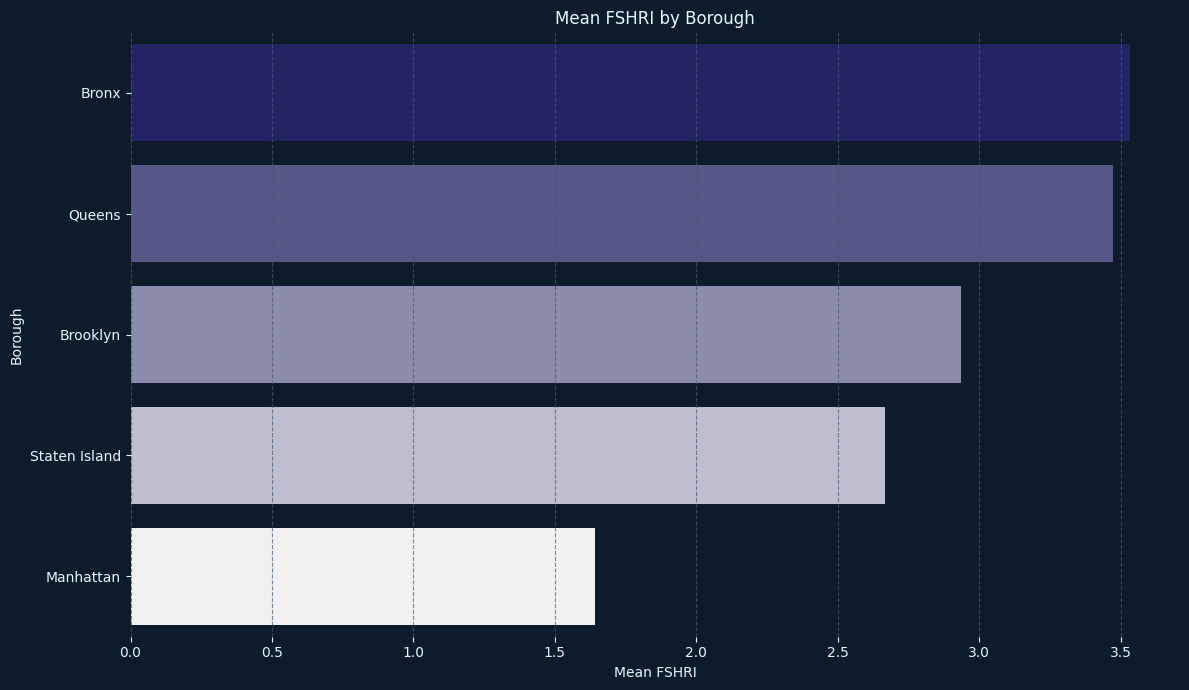

In [23]:
# Define the ocean-floor palette colors for consistency
fig_bg_color = '#0D1B2A'
ax_face_color = '#0D1B2A'
grid_color = '#415A77'
font_color = '#E0FBFC'

# Calculate mean FSHRI for each Borough and sort them
# Drop rows where FSHRI is NaN for this calculation
fshri_by_borough = final_gdf.dropna(subset=['FSHRI']).groupby('Borough')['FSHRI'].mean().sort_values(ascending=False)

# Create a DataFrame for plotting
plot_df_mean = fshri_by_borough.reset_index()
plot_df_mean.columns = ['Borough', 'Mean FSHRI']

# Define a custom color palette for the boroughs, from dark to light blue
# The number of colors should match the number of unique boroughs
num_boroughs = len(plot_df_mean['Borough'].unique())

# Using seaborn's light_palette from a dark blue to get shades of ocean-like colors
# Reversed to go from darkest for highest FSHRI to lightest for lowest FSHRI
borough_colors = sns.light_palette("midnightblue", n_colors=num_boroughs, reverse=True)

# Map colors to boroughs based on sorted FSHRI
color_map = {borough: borough_colors[i] for i, borough in enumerate(plot_df_mean['Borough'])}

plt.figure(figsize=(12, 7), facecolor=fig_bg_color) # Set figure background
ax = sns.barplot(
    x='Mean FSHRI',
    y='Borough',
    data=plot_df_mean,
    palette=color_map, # Apply the custom color map
    order=plot_df_mean['Borough'] # Ensure the order is maintained
)

# Set the facecolor of the axes to a slightly lighter dark blue
ax.set_facecolor(ax_face_color)

plt.title('Mean FSHRI by Borough', color=font_color)
plt.xlabel('Mean FSHRI', color=font_color)
plt.ylabel('Borough', color=font_color)
plt.xticks(color=font_color)
plt.yticks(color=font_color)

# Set tick label colors to a very light blue/cyan
ax.tick_params(axis='x', colors=font_color)
ax.tick_params(axis='y', colors=font_color)

# Set grid lines only for the x-axis for a horizontal bar chart
ax.grid(axis='x', linestyle='--', alpha=0.7, color=grid_color)
ax.grid(axis='y', visible=False) # Ensure y-axis grid is off

# Remove all borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

The following code is designed to run a linear regression between FSHRI and median household income values. The first code block is primarily designed to visualize the correlation, while the second runs an Ordinary Least Squares (OLS) regression and prints results as a table.

Intercept: 4.406248485790116
Coefficient for Median Income: -1.565089360088945e-05
R-squared: 0.2281


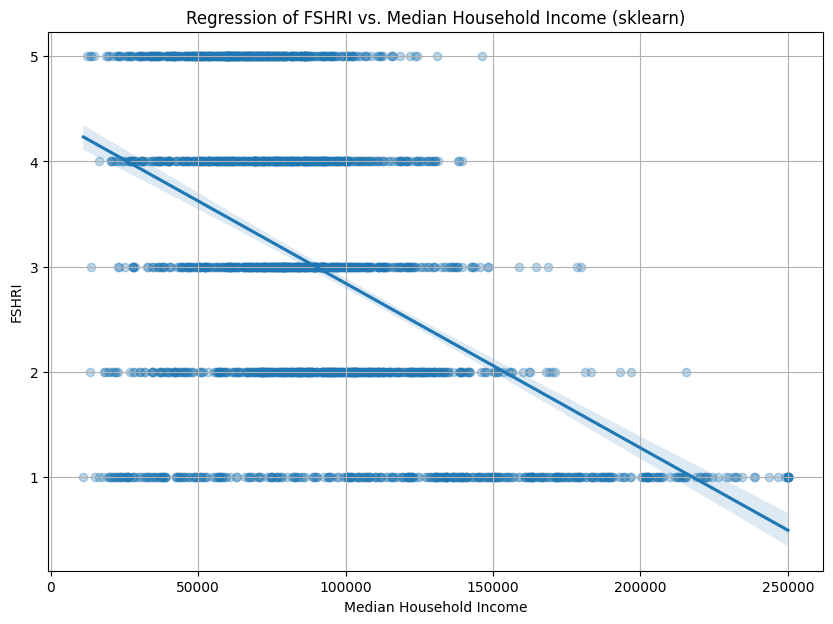

In [24]:
# Calculating reression statistics and visualizing them in plot form

# Import libraries
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Prepare the data for regression (re-using regression_data from previous step)
# Ensure 'Median Income' is numeric and drop NaNs
regression_data = final_gdf[['FSHRI', 'Median Income']].dropna()
regression_data['Median Income'] = pd.to_numeric(regression_data['Median Income'], errors='coerce')
regression_data = regression_data.dropna()

# Define features (X) and target (y)
X = regression_data[['Median Income']]
y = regression_data['FSHRI']

# Create and fit the linear regression model
model_sklearn = LinearRegression()
model_sklearn.fit(X, y)

# Print the coefficients and intercept
print(f"Intercept: {model_sklearn.intercept_}")
print(f"Coefficient for Median Income: {model_sklearn.coef_[0]}")

# Optional: You can also calculate R-squared
r_squared = model_sklearn.score(X, y)
print(f"R-squared: {r_squared:.4f}")

# Visualize the regression
plt.figure(figsize=(10, 7))
sns.regplot(x='Median Income', y='FSHRI', data=regression_data, scatter_kws={'alpha':0.3})
plt.title('Regression of FSHRI vs. Median Household Income (sklearn)')
plt.xlabel('Median Household Income')
plt.ylabel('FSHRI')
plt.grid(True)
plt.show()

In [25]:
# Calculating regression statistics and visualizing them in table form

# Import libraries
import statsmodels.formula.api as smf

# Prepare the data for regression (using the same regression_data as before)
# Ensure 'Median Income' is numeric and drop NaNs
regression_data = final_gdf[['FSHRI', 'Median Income']].dropna()
regression_data['Median Income'] = pd.to_numeric(regression_data['Median Income'], errors='coerce')
regression_data = regression_data.dropna()

# Run the regression using statsmodels
model_sm = smf.ols('FSHRI ~ Q("Median Income")', data=regression_data)
results_sm = model_sm.fit()

# Print the summary to get the p-value
print(results_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  FSHRI   R-squared:                       0.228
Model:                            OLS   Adj. R-squared:                  0.228
Method:                 Least Squares   F-statistic:                     645.6
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          5.32e-125
Time:                        18:41:18   Log-Likelihood:                -3574.3
No. Observations:                2187   AIC:                             7153.
Df Residuals:                    2185   BIC:                             7164.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.4062      0

The p-value in this regression is almost 0, indicating a statistically significant relationship between FSHRI scores and median household income. However, it is worth noting that poverty levels were included as one of 12 variables used to calculate FSHRI scores, which could contribute to redundancy in features.

The following plot simply re-formats the graph of FSHRI vs. Median Income for visualization purposes.

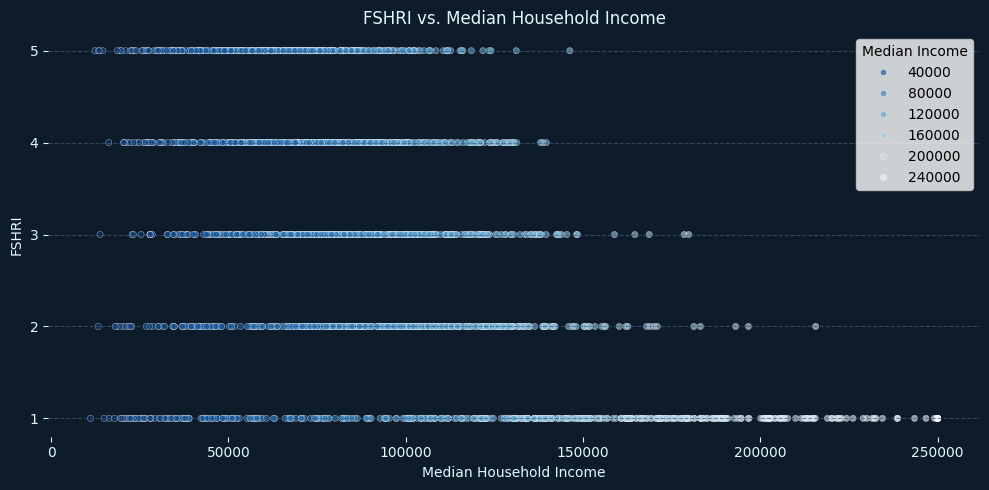

In [26]:
# Set plot background and theme
plt.figure(figsize=(10, 5), facecolor='#0D1B2A') # Very dark blue figure background
ax = sns.scatterplot(x='Median Income', y='FSHRI', data=regression_data, alpha=0.6, s=20,
                hue='Median Income', palette="Blues_r") # Use a reversed blue colormap for ocean theme

# Set the facecolor of the axes to a slightly lighter dark blue
ax.set_facecolor('#0D1B2A')

# Set grid lines only for the y-axis
plt.grid(axis='y', linestyle='--', alpha=0.7, color='#415A77') # Medium dark blue-grey grid lines
plt.grid(axis='x', visible=False) # Ensure x-axis grid is off

# Set y-axis ticks to show increments from 1 to 5
plt.yticks([1, 2, 3, 4, 5])

# Remove all borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Set title and labels in a very light blue/cyan
plt.title('FSHRI vs. Median Household Income', color='#E0FBFC')
plt.xlabel('Median Household Income', color='#E0FBFC')
plt.ylabel('FSHRI', color='#E0FBFC')

# Set tick label colors to a very light blue/cyan
ax.tick_params(axis='x', colors='#E0FBFC')
ax.tick_params(axis='y', colors='#E0FBFC')

plt.tight_layout()
plt.show()